# $F_D$ on a slab-normal plane vs a vertical plane

At the trench the plate has begun to bend, so a vertical plane is no longer truly plate-perpendicular. The standard differential-stress resultant

$$F_D \;=\; \int_0^{z_\max}(\tau_{xx} - \tau_{zz})\,dz$$

evaluated on a vertical plane through the trench therefore mixes plate-parallel and plate-perpendicular stress components. Here we recompute $F_D$ on a **truly slab-normal plane** and compare.

**Steps.** (1) estimate the local dip $\theta$ from the angle of an isotherm in the lithosphere interior near the trench; (2) build a slab-normal integration path from the trench surface point in direction $(-\sin\theta, \cos\theta)$; (3) sample $\tau_{xx}, \tau_{zz}, \tau_{xz}$ along that path; (4) rotate the deviatoric stress into slab coordinates $(\xi, \eta)$ where $\xi$ is slab-parallel and $\eta$ is slab-perpendicular:

$$\tau_{\xi\xi} - \tau_{\eta\eta} \;=\; (\tau_{xx} - \tau_{zz})\cos 2\theta + 2\tau_{xz}\sin 2\theta$$

(5) integrate along $\eta$.

Setup duplicates `cerpa_single_step.ipynb` (config, helpers, grid) so `MODEL_KEY` and `TIMESTEP_INDEX` work the same way.

## 1. Setup & imports

In [1]:
import numpy as np
if not hasattr(np, 'trapz'): np.trapz = np.trapezoid  # numpy 2.x compat
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

Same as `cerpa_single_step.ipynb`. Change `MODEL_KEY` / `TIMESTEP_INDEX` to swap.

In [52]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY      = 'WAL'
TIMESTEP_INDEX = 10

DX        = 1000.0
Z_MAX     = 500_000.0
Y_SURFACE = 2_900_000.0

fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
i = TIMESTEP_INDEX if TIMESTEP_INDEX >= 0 else len(pvtu_files) + TIMESTEP_INDEX
ff = pvtu_files[i]
print(f"Model {MODEL_KEY!r} timestep {i}: {ff.split('/')[-1]}")

# === Mirror flag ============================================================
# When True, every extracted field is mirrored along x so that subduction
# matches the MDOODZ convention (subducting plate on the right, vx < 0).
# Derived constants below propagate this choice to direction-dependent code.
MIRROR_X        = True
SUBDUCTING_SIDE = "right" if MIRROR_X else "left"
SEAWARD_SIGN    = +1     if MIRROR_X else -1   # use as: tloc + SEAWARD_SIGN * offset_metres
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")


Model 'WAL' timestep 10: subduction_with_LM_10.pvtu
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


## 3. Helpers

`get_field` reshapes a sampled VTK array onto the regular grid. The 3-step trench picker (and its sub-helpers) is duplicated from `cerpa_single_step.ipynb`.

In [53]:
import sys
from pathlib import Path
# cerpa_helpers lives in notebooks/, one level above further_analysis/
_helpers_dir = str(Path("..").resolve())
if _helpers_dir not in sys.path:
    sys.path.insert(0, _helpers_dir)

from cerpa_helpers import (
    make_field_extractor,
    mirror_fields_in_x,
    pick_trench_3step,
    find_first_isostatic_column,
    find_ridge_x,
    col_avg,
    norm01,
    load_records,
)


## 4. Load PVTU and build the regular grid

Sample the unstructured Fluidity output onto a uniform `DX`-spaced grid; extract $T$, $p$, $\tau_{xx}, \tau_{zz}, \tau_{xz}$, and $v_x$ as 2-D arrays indexed `[z, x]`.

In [54]:
vtk_data = pv.read(ff)
t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / 31_557_600.0

# === Coordinate convention =================================================
# Model frame: (x, y) with y vertical UP.  Notebook frame: (x, z) with
# z = Y_SURFACE - y, depth positive DOWN.  The reflection y -> -z flips
# off-diagonal stress components: sigma_xz_zdown = -sigma_xy_yup.  We apply
# that flip HERE at extraction so all downstream code is in z-down convention.
vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]   # sigma_xz_zdown = -sigma_xy_yup
vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
vtk_data.point_data['vx']  = vel[:, 0]
vtk_data.point_data['vy']  = vel[:, 1]

x_min, x_max, _, _, _, _ = vtk_data.bounds
nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
x = x_min + (np.arange(nx) + 0.5) * DX
z = (np.arange(nz) + 0.5) * DX
X, Z = np.meshgrid(x, z, indexing='xy')
Y = Y_SURFACE - Z
grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
interp = grid.sample(vtk_data)
nx_pv, nz_pv, _ = interp.dimensions
valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)
get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)

p   = get_field('p')
txx = get_field('txx')
tzz = get_field('tzz')
txz = get_field('txz')
T   = get_field('T')
fs  = get_field('fs')
vx  = get_field('vx')
vz  = -get_field('vy')

# === Apply x-mirror ==========================================================
if MIRROR_X:
    p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)
    print('(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)')

print(f'grid: {p.shape}  x in [{x[0]/1e3:.0f}, {x[-1]/1e3:.0f}] km, z in [{z[0]/1e3:.1f}, {z[-1]/1e3:.1f}] km')


(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)
grid: (500, 7999)  x in [0, 7998] km, z in [0.5, 499.5] km


## 5. Trench identification

In [55]:
tloc, info = pick_trench_3step(
    x, z, p, vx,
    vx_depth_m=5000, Wv_km=800, Wp3_km=800,
    smooth_km=40, subducting_side=SUBDUCTING_SIDE,
)
tindx = int(np.argmin(np.abs(x - tloc)))
print(f'Trench at x = {tloc/1e3:.1f} km (index {tindx})')


Trench at x = 4440.5 km (index 4440)


## 6. Slab dip from interior isotherm

Pick an isotherm well inside the lithosphere (`T_ISO ~ 600-800°C`). For each $x$ in a symmetric window of half-width `WINDOW_KM` around the trench, find the depth where $T(x, z) = T_\mathrm{iso}$ and fit a line to those points. The slope gives $\tan\theta$.

In [56]:
T_ISO     = 800.0   # °C — middle of lithosphere
WINDOW_KM = 10      # half-width of symmetric window (± WINDOW_KM around trench)

x_lo = tloc - WINDOW_KM * 1000.0
x_hi = tloc + WINDOW_KM * 1000.0
ix_window = np.where((x >= x_lo) & (x <= x_hi))[0]

z_iso = []
for ix in ix_window:
    Tcol = T[:, ix]
    if not np.all(np.isfinite(Tcol)) or T_ISO <= Tcol[0] or T_ISO >= Tcol[-1]:
        z_iso.append(np.nan)
        continue
    z_iso.append(np.interp(T_ISO, Tcol, z))
z_iso = np.array(z_iso)
x_window = x[ix_window]

good = np.isfinite(z_iso)
m, b = np.polyfit(x_window[good], z_iso[good], 1)
dip = float(np.arctan(m))   # in radians
print(f'Slab dip from {T_ISO:.0f}°C isotherm (over ±{WINDOW_KM} km around trench): {np.rad2deg(dip):.2f}°')
print(f'  isotherm depth at trench  ≈ {b + m*tloc:7.0f} m  ({(b + m*tloc)/1e3:.1f} km)')

Slab dip from 800°C isotherm (over ±10 km around trench): -3.10°
  isotherm depth at trench  ≈   28485 m  (28.5 km)


## 7. Build slab-normal integration path and sample stresses

Slab-normal direction (into the rock from the surface): $\hat{\eta} = (-\sin\theta, \cos\theta)$. Path starts at the trench surface point and steps along $\hat{\eta}$ for length $L$.

In [57]:
L_PATH = Z_MAX             # length along slab-normal path (m); same as vertical extent
DS     = 500.0             # step size along path (m)

n_steps = int(L_PATH / DS) + 1
s_path = np.arange(n_steps) * DS

nx_hat = -np.sin(dip)      # slab-normal direction
nz_hat = +np.cos(dip)

x_path = tloc + s_path * nx_hat
z_path = z[0] + s_path * nz_hat   # start at first row of grid (z = 500 m), not z = 0

# Interpolate stresses along the path
def make_interp(field):
    return RegularGridInterpolator((z, x), field, bounds_error=False, fill_value=np.nan)

fT   = make_interp(T)
ftxx = make_interp(txx)
ftzz = make_interp(tzz)
ftxz = make_interp(txz)

pts = np.column_stack([z_path, x_path])
T_path   = fT(pts)
txx_path = ftxx(pts)
tzz_path = ftzz(pts)
txz_path = ftxz(pts)

# Rotated differential stress: τ_ξξ - τ_ηη
two_theta = 2 * dip
diff_rotated  = (txx_path - tzz_path) * np.cos(two_theta) + 2 * txz_path * np.sin(two_theta)
diff_vertical = txx[:, tindx] - tzz[:, tindx]   # along the vertical column

## 8. $F_D$ — vertical vs slab-normal


F_D on vertical   plane:   -0.678  TN/m
F_D on slab-normal plane:  -0.549  TN/m
difference:  +0.128  TN/m
(slab-normal − vertical) / vertical = -19.0 %


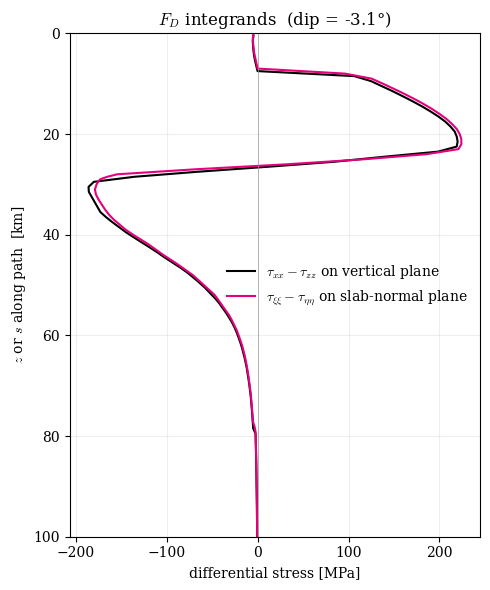

In [58]:
F_D_vertical    = np.trapz(diff_vertical, z)
F_D_slab_normal = np.trapz(diff_rotated[np.isfinite(diff_rotated)],
                            s_path[np.isfinite(diff_rotated)])

print(f'F_D on vertical   plane:  {F_D_vertical    * 1e-12:+7.3f}  TN/m')
print(f'F_D on slab-normal plane: {F_D_slab_normal * 1e-12:+7.3f}  TN/m')
print(f'difference: {(F_D_slab_normal - F_D_vertical)*1e-12:+7.3f}  TN/m')
print(f'(slab-normal − vertical) / vertical = {(F_D_slab_normal/F_D_vertical - 1)*100:+.1f} %' if F_D_vertical != 0 else '')

# Plot the integrand on each path so you can see WHERE F_D comes from
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(diff_vertical*1e-6, z*1e-3, 'k-', lw=1.5, label=r'$\tau_{xx}-\tau_{zz}$ on vertical plane')
ax.plot(diff_rotated *1e-6, s_path*1e-3, color='#E5007D', lw=1.5,
        label=r'$\tau_{\xi\xi}-\tau_{\eta\eta}$ on slab-normal plane')
ax.axvline(0, color='0.6', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('differential stress [MPa]')
ax.set_ylabel(r'$z$ or $s$ along path  [km]')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
ax.set_ylim(100, 0)
ax.set_title(f'$F_D$ integrands  (dip = {np.rad2deg(dip):.1f}°)')
fig.tight_layout()
plt.show()

## 9. Visualisation — verify the path orientation

Zoomed view of the trench region with: temperature field as background, the chosen isotherm (gold), the linear dip fit (dashed), the vertical line and the slab-normal path. Use this to confirm the slab-normal path actually follows the lithosphere.

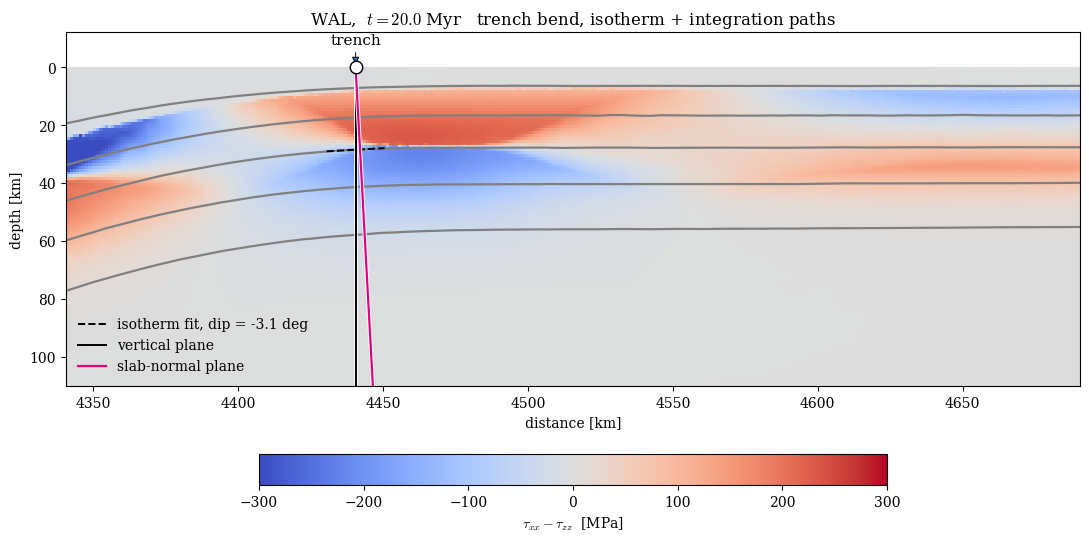

In [59]:
# After x-mirror the trailing plate is on the right and the slab descends
# leftward, so the asymmetric zoom shows mostly +x relative to the trench.
WIN_X_KM = 250
WIN_Z_KM = 110
x_lo_v = tloc - 100e3
x_hi_v = tloc + WIN_X_KM * 1e3
ix_v   = (x >= x_lo_v) & (x <= x_hi_v)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.pcolormesh(x[ix_v]*1e-3, z*1e-3,                                                                                                                                                             
                     (txx[:, ix_v] - tzz[:, ix_v]) * 1e-6,    # Pa -> MPa
                     cmap='coolwarm', shading='auto', vmin=-300, vmax=300)            

cbar = fig.colorbar(im, ax=ax,                            
                      label=r'$\tau_{xx} - \tau_{zz}$  [MPa]',                                                                                                                                         
                      orientation='horizontal', fraction=0.06, pad=0.13)

ax.contour(x[ix_v]*1e-3, z*1e-3, T[:, ix_v], levels=[400, 600, 800, 1000, 1200],
           colors='grey', linewidths=1.6)

x_fit = np.linspace(x_window.min(), x_window.max(), 60)
ax.plot(x_fit*1e-3, (m*x_fit + b)*1e-3, 'k--', lw=1.4,
        label=f'isotherm fit, dip = {np.rad2deg(dip):.1f} deg')

ax.plot([tloc*1e-3, tloc*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='white', lw=2.6)
ax.plot([tloc*1e-3, tloc*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='black', lw=1.4, label='vertical plane')

ax.plot(x_path*1e-3, z_path*1e-3, color='white', lw=3.0)
ax.plot(x_path*1e-3, z_path*1e-3, color='#E5007D', lw=1.6, label='slab-normal plane')

ax.plot(tloc*1e-3, 0, 'wo', mec='k', ms=9, zorder=5)
ax.annotate('trench', xy=(tloc*1e-3, 0), xytext=(tloc*1e-3, -8),
            ha='center', fontsize=11,
            arrowprops=dict(arrowstyle='-|>', lw=0.7))

ax.invert_yaxis()
ax.set_xlim(x_lo_v*1e-3, x_hi_v*1e-3)
ax.set_ylim(WIN_Z_KM, -12)
ax.set_xlabel('distance [km]')
ax.set_ylabel('depth [km]')
ax.set_aspect('equal')
ax.legend(loc='lower left', frameon=False, fontsize=10)
ax.set_title(f'{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr   trench bend, isotherm + integration paths')
fig.tight_layout()

figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'slab_normal_path_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',
            bbox_inches='tight', dpi=200)
plt.show()


## 10. Time loop — $F_D$ across all snapshots

Repeat the §4–§8 recipe at every snapshot.  Capture three arrays:

- `Fd_vert_arr` — $F_D$ on a vertical plane through the trench
- `Fd_slabn_arr` — $F_D$ on the slab-normal plane (rotated deviatoric stress, integrated along the slab-normal path)
- `Fd_slabn_h_arr` — horizontal projection of the slab-normal resultant, $F_D^{slab-normal}\cos\theta$


In [ ]:
import gc
from scipy.interpolate import RegularGridInterpolator

t_yr_arr       = []
Fd_vert_arr    = []
Fd_slabn_arr   = []
Fd_slabn_h_arr = []        # horizontal projection: F_D_slab_normal * cos(dip)
dip_arr        = []

for i_step, ff_step in enumerate(pvtu_files):
    if i_step == 0:
        continue
    try:
        # --- read pvtu --------------------------------------------------
        vd = pv.read(ff_step)
        t_yr_s = float(np.asarray(vd['NormalSP::Time']).flat[0]) / 31_557_600.0
        vd.point_data['p']   = vd['NormalSP::Pressure']
        vd.point_data['txx'] = vd['NormalSP::Stress'][:, 0]
        vd.point_data['tzz'] = vd['NormalSP::Stress'][:, 4]
        vd.point_data['txz'] = -vd['NormalSP::Stress'][:, 1]
        vd.point_data['T']   = vd['NormalSP::Temperature']
        vd.point_data['vx']  = (vd['NormalSP::Velocity'] / 3.17098e-10)[:, 0]

        # --- grid + interpolate ----------------------------------------
        x_min_s, x_max_s, _, _, _, _ = vd.bounds
        nx_s = int((x_max_s - x_min_s) / DX); nz_s = int(Z_MAX / DX)
        x_s = x_min_s + (np.arange(nx_s) + 0.5) * DX
        z_s = (np.arange(nz_s) + 0.5) * DX
        Xs, Zs = np.meshgrid(x_s, z_s, indexing='xy')
        Ys = Y_SURFACE - Zs
        gs = pv.StructuredGrid(Xs.T, Ys.T, np.zeros_like(Xs.T))
        ip = gs.sample(vd)
        nxp, nzp, _ = ip.dimensions
        vmask = ip['vtkValidPointMask'].reshape((nxp, nzp), order='F').astype(bool)
        gf = make_field_extractor(ip, nxp, nzp, vmask)

        p_s   = gf('p');   txx_s = gf('txx'); tzz_s = gf('tzz')
        txz_s = gf('txz'); T_s   = gf('T');   vx_s  = gf('vx')
        if MIRROR_X:
            zero = np.zeros_like(p_s)
            p_s, txx_s, tzz_s, txz_s, T_s, _, vx_s, _ = mirror_fields_in_x(
                p_s, txx_s, tzz_s, txz_s, T_s, zero, vx_s, zero)

        # --- trench -----------------------------------------------------
        tloc_s, _ = pick_trench_3step(
            x_s, z_s, p_s, vx_s,
            vx_depth_m=5000, Wv_km=800, Wp3_km=800,
            smooth_km=40, subducting_side=SUBDUCTING_SIDE,
        )
        tindx_s = int(np.argmin(np.abs(x_s - tloc_s)))

        # --- dip from isotherm window ----------------------------------
        x_lo_s = tloc_s - WINDOW_KM * 1000.0
        x_hi_s = tloc_s + WINDOW_KM * 1000.0
        ixw = np.where((x_s >= x_lo_s) & (x_s <= x_hi_s))[0]
        zi = []
        for ix in ixw:
            Tc = T_s[:, ix]
            if not np.all(np.isfinite(Tc)) or T_ISO <= Tc[0] or T_ISO >= Tc[-1]:
                zi.append(np.nan); continue
            zi.append(np.interp(T_ISO, Tc, z_s))
        zi = np.array(zi)
        good = np.isfinite(zi)
        if good.sum() < 3:
            raise RuntimeError('isotherm fit has too few points')
        ms, bs = np.polyfit(x_s[ixw][good], zi[good], 1)
        dip_s = float(np.arctan(ms))

        # --- slab-normal path + integrand ------------------------------
        nxh = -np.sin(dip_s); nzh = +np.cos(dip_s)
        x_path_s = tloc_s + s_path * nxh
        z_path_s = z_s[0] + s_path * nzh
        ft_xx = RegularGridInterpolator((z_s, x_s), txx_s, bounds_error=False, fill_value=np.nan)
        ft_zz = RegularGridInterpolator((z_s, x_s), tzz_s, bounds_error=False, fill_value=np.nan)
        ft_xz = RegularGridInterpolator((z_s, x_s), txz_s, bounds_error=False, fill_value=np.nan)
        pts = np.column_stack([z_path_s, x_path_s])
        txx_p = ft_xx(pts); tzz_p = ft_zz(pts); txz_p = ft_xz(pts)
        two_th = 2 * dip_s
        diff_rot  = (txx_p - tzz_p) * np.cos(two_th) + 2 * txz_p * np.sin(two_th)
        diff_vert = txx_s[:, tindx_s] - tzz_s[:, tindx_s]

        F_vert  = np.trapz(diff_vert, z_s)
        fin = np.isfinite(diff_rot)
        F_slabn = np.trapz(diff_rot[fin], s_path[fin])
        F_slabn_h = F_slabn * np.cos(dip_s)

        t_yr_arr.append(t_yr_s)
        Fd_vert_arr.append(F_vert)
        Fd_slabn_arr.append(F_slabn)
        Fd_slabn_h_arr.append(F_slabn_h)
        dip_arr.append(dip_s)

        if i_step % 5 == 0:
            print(f'  [{i_step:>3}] t = {t_yr_s/1e6:5.2f} Myr  '
                  f'dip = {np.rad2deg(dip_s):5.1f}°   '
                  f'F_vert = {F_vert*1e-12:+6.2f}   '
                  f'F_slabn = {F_slabn*1e-12:+6.2f}   '
                  f'F_slabn_h = {F_slabn_h*1e-12:+6.2f}  TN/m')

        del vd, gs, ip
        gc.collect()
    except Exception as e:
        print(f'  [{i_step}] failed: {e}; skipping')
        continue

t_yr_arr       = np.array(t_yr_arr)
Fd_vert_arr    = np.array(Fd_vert_arr)
Fd_slabn_arr   = np.array(Fd_slabn_arr)
Fd_slabn_h_arr = np.array(Fd_slabn_h_arr)
dip_arr        = np.array(dip_arr)

print(f'\ncaptured {len(t_yr_arr)} snapshots')


## 11. Plot — $F_D$ vs time on the three planes


NameError: name 't_yr_arr' is not defined

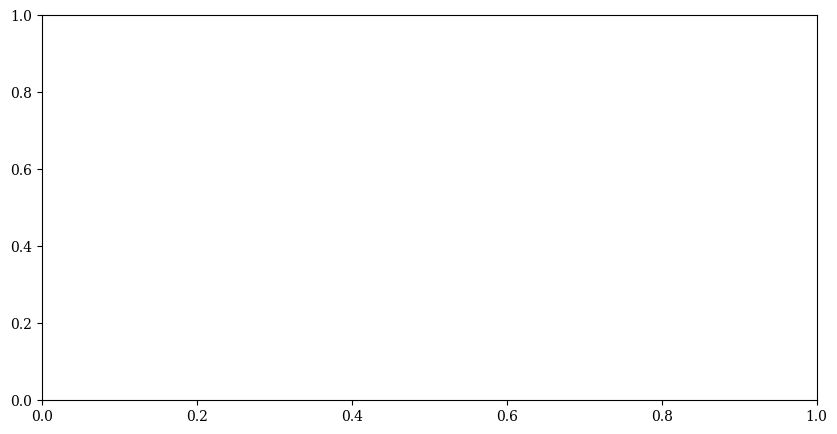

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_yr_arr/1e6, Fd_vert_arr    * 1e-12, color='green',     ls='-',  lw=1.8,
        label=r'$F_D$ on vertical plane')
ax.plot(t_yr_arr/1e6, Fd_slabn_arr   * 1e-12, color='blue',  ls='-',  lw=1.8,
        label=r'$F_D$ on slab-normal plane')
ax.plot(t_yr_arr/1e6, Fd_slabn_h_arr * 1e-12, color='blue',  ls='--', lw=1.8,
        label=r'$F_D$ on slab-normal plane $\times\cos\theta$  (horizontal projection)')
ax.axhline(0, color='0.7', lw=0.5)
ax.set_xlabel('time [Myr]')
ax.set_ylabel(r'$F_D$  [TN/m]')
ax.set_title(f'{MODEL_KEY}  —  $F_D$ across all snapshots: vertical vs slab-normal plane')
ax.legend(loc='best', frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()

figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'slab_normal_FD_evolution_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()


## 12. $F_D$ along the slab-top SP boundary

§8 evaluates $F_D$ on a single slab-normal plane through the trench. This section extends that to a *series* of slab-normal planes along the slab top, walking from the trailing-plate lithosphere through the trench bend and down into the deep slab.

**Pipeline.** Trace the contour of the subducting-plate material fraction at $\mathrm{SP}=0.5$ — the actual slab-top boundary, including the trailing-plate continuation just below the weak layer. Walk the polyline in both directions from a seed near the trench, smooth it with a Gaussian filter, fit a cubic spline, sample uniformly in arc length. At each evaluation point compute the local dip from the spline tangent, build a slab-normal line, sample stresses, mask, integrate.

**Outputs.**
- $F_D$ on each slab-normal plane
- $F_D\cos\theta$ — horizontal projection
- $F_D\sin\theta$ — vertical projection (sign-corrected to "downward = positive" in plotting)
- local dip $\theta$ from the spline tangent

all as functions of arc length from the trench and depth of the eval point.

The geometry-only quantity used here is the SP-boundary contour. Temperature appears only inside the mask (see "Masking strategy" below); it never enters the geometry calculation.

In [60]:
# F_D along the slab-top SP boundary — F_D + buoyancy + interface-shear pipeline.
#
# Drop into a fresh cell in fluidity_slab_normal_FD.ipynb after §6.  Requires:
#   x, z, T, txx, tzz, txz             (from §4 load cell)
#   tloc, tindx                        (from §5 trench picker)
#   vtk_data, grid, interp, nx_pv,
#   nz_pv, valid                       (still in scope from §4)
#   MIRROR_X, SEAWARD_SIGN, MODEL_KEY, t_yr, DX

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, RegularGridInterpolator
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import cumulative_trapezoid
import contourpy

# ---- 0. Extract SP material fraction + density ----------------------------
vtk_data.point_data['sp']  = vtk_data['NormalSP::MaterialVolumeFraction']
vtk_data.point_data['rho'] = vtk_data['NormalSP::Density']
interp_aux = grid.sample(vtk_data)

SP = interp_aux['sp'].reshape((nx_pv, nz_pv), order='F')
SP[~valid] = np.nan
SP = SP.T
if MIRROR_X:
    SP = np.flip(SP, axis=1)

RHO = interp_aux['rho'].reshape((nx_pv, nz_pv), order='F')
RHO[~valid] = np.nan
RHO = RHO.T
if MIRROR_X:
    RHO = np.flip(RHO, axis=1)

# ---- 1. Parameters ---------------------------------------------------------
SP_LEVEL                = 0.5
SEED_X_M                = tloc
SEED_Z_M                = 5_000.0
EVAL_STEP_KM            = 10.0
MAX_DEPTH_KM            = 400.0
SMOOTH_SIGMA_PTS        = 20
TURNING_POINT_TOL_M     = 5_000.0
DECOUPLING_DEPTH_KM     = 100.0

EXTEND_BACK_KM          = 400.0

SLAB_NORMAL_UP_KM       = 20.0
SLAB_NORMAL_DOWN_KM     = 120.0
DS_PATH_M               = 1_000.0

SP_THRESHOLD_MASK       = 0.5
T_MAX_K                 = 1273.0

# Buoyancy
G_GRAV                  = 9.8
RHO_REF_FALLBACK        = 3300.0

# Interface shear (semi-analytical: constant tau on the slab top, applied
# only down-dip of the trench, acting in the up-dip direction).
TAU_INTERFACE_MPA       = 20.0
TAU_INTERFACE_PA        = TAU_INTERFACE_MPA * 1e6

# ---- 2. Trace the SP=0.5 boundary -----------------------------------------
gen = contourpy.contour_generator(x=x, y=z, z=SP)
segments = gen.lines(SP_LEVEL)

flat_pts  = np.vstack(segments)
seg_owner = np.concatenate([np.full(len(s), i) for i, s in enumerate(segments)])
seed = np.array([SEED_X_M, SEED_Z_M])
nearest_flat = int(np.argmin(np.linalg.norm(flat_pts - seed, axis=1)))
chosen_full = segments[seg_owner[nearest_flat]]

# ---- 3. Walk the polyline in BOTH directions from the seed ----------------
seed_idx = int(np.argmin(np.linalg.norm(chosen_full - seed, axis=1)))
test_step = min(20, len(chosen_full) - seed_idx - 1, seed_idx)
fwd_dz = chosen_full[min(seed_idx + test_step, len(chosen_full)-1), 1] - chosen_full[seed_idx, 1]
bwd_dz = chosen_full[max(seed_idx - test_step, 0), 1] - chosen_full[seed_idx, 1]

if fwd_dz > bwd_dz:
    slab_side  = chosen_full[seed_idx:]
    plate_side = chosen_full[:seed_idx][::-1]
else:
    slab_side  = chosen_full[:seed_idx + 1][::-1]
    plate_side = chosen_full[seed_idx + 1:]

z_running = slab_side[:, 1]
cummax    = np.maximum.accumulate(z_running)
turning   = np.where(z_running < cummax - TURNING_POINT_TOL_M)[0]
stop_idx  = turning[0] if len(turning) > 0 else len(slab_side)
slab_side = slab_side[:stop_idx]
slab_side = slab_side[slab_side[:, 1] < MAX_DEPTH_KM * 1_000.0]

if EXTEND_BACK_KM > 0 and len(plate_side) > 0:
    dist_from_trench = np.abs(plate_side[:, 0] - tloc)
    plate_side = plate_side[dist_from_trench < EXTEND_BACK_KM * 1_000.0]
else:
    plate_side = plate_side[:0]

walk = np.vstack([plate_side[::-1], slab_side])
print(f'walked: plate_side={len(plate_side)} pts, slab_side={len(slab_side)} pts, '
      f'combined={len(walk)} pts')

# ---- 4. Smooth the combined polyline --------------------------------------
slab_top = walk.copy()
slab_top[:, 0] = gaussian_filter1d(slab_top[:, 0], sigma=SMOOTH_SIGMA_PTS)
slab_top[:, 1] = gaussian_filter1d(slab_top[:, 1], sigma=SMOOTH_SIGMA_PTS)
print(f'depth range: {slab_top[0,1]/1e3:.1f} -> {slab_top[-1,1]/1e3:.1f} km')

# ---- 5. Reparametrise by arc length, sample uniformly ---------------------
ds_seg = np.linalg.norm(np.diff(slab_top, axis=0), axis=1)
s_raw  = np.concatenate([[0.0], np.cumsum(ds_seg)])
spline_x = CubicSpline(s_raw, slab_top[:, 0])
spline_z = CubicSpline(s_raw, slab_top[:, 1])

s_eval   = np.arange(0, s_raw[-1], EVAL_STEP_KM * 1_000.0)
x_eval   = spline_x(s_eval)
z_eval   = spline_z(s_eval)
dxds     = spline_x(s_eval, 1)
dzds     = spline_z(s_eval, 1)

i_trench = int(np.argmin(np.hypot(x_eval - tloc, z_eval)))
s_arc    = s_eval - s_eval[i_trench]

ds_norm  = np.hypot(dxds, dzds)
tx, tz   = dxds / ds_norm, dzds / ds_norm
nx_hat   = +tz
nz_hat   = -tx

dip_eval = np.arctan(dzds / np.where(dxds == 0, 1e-12, dxds))

# ---- 6. Build asymmetric slab-normal lines --------------------------------
n_up   = int(SLAB_NORMAL_UP_KM   * 1_000.0 / DS_PATH_M)
n_down = int(SLAB_NORMAL_DOWN_KM * 1_000.0 / DS_PATH_M)
s_local = np.arange(-n_up, n_down + 1) * DS_PATH_M

X_lines = x_eval[:, None] + s_local[None, :] * nx_hat[:, None]
Z_lines = z_eval[:, None] + s_local[None, :] * nz_hat[:, None]

# ---- 7. Sample stresses + density; mask; integrate F_D and buoyancy ------
ftxx = RegularGridInterpolator((z, x), txx, bounds_error=False, fill_value=np.nan)
ftzz = RegularGridInterpolator((z, x), tzz, bounds_error=False, fill_value=np.nan)
ftxz = RegularGridInterpolator((z, x), txz, bounds_error=False, fill_value=np.nan)
fT   = RegularGridInterpolator((z, x), T,   bounds_error=False, fill_value=np.nan)
fSP  = RegularGridInterpolator((z, x), SP,  bounds_error=False, fill_value=0.0)
frho = RegularGridInterpolator((z, x), RHO, bounds_error=False, fill_value=np.nan)

Fd_arr      = np.full(len(s_eval), np.nan)
Fd_h_arr    = np.full(len(s_eval), np.nan)
Fd_v_arr    = np.full(len(s_eval), np.nan)
sigma_arr   = np.full(len(s_eval), np.nan)
dW_ds_arr   = np.full(len(s_eval), np.nan)
rho_ref_arr = np.full(len(s_eval), np.nan)

for i in range(len(s_eval)):
    pts = np.column_stack([Z_lines[i], X_lines[i]])
    txx_p = ftxx(pts); tzz_p = ftzz(pts); txz_p = ftxz(pts)
    T_p   = fT(pts);   SP_p  = fSP(pts);   rho_p = frho(pts)

    two_th   = 2 * dip_eval[i]
    diff_rot = (txx_p - tzz_p) * np.cos(two_th) + 2 * txz_p * np.sin(two_th)

    z_along      = pts[:, 0]
    shallow      = z_along < DECOUPLING_DEPTH_KM * 1_000.0
    mask_shallow = (SP_p > SP_THRESHOLD_MASK) & (T_p < T_MAX_K)
    mask_deep    = (T_p < T_MAX_K)
    keep = np.where(shallow, mask_shallow, mask_deep) & np.isfinite(diff_rot)

    if keep.sum() < 2:
        continue

    Fd_arr[i]   = np.trapz(diff_rot[keep], s_local[keep])
    Fd_h_arr[i] = Fd_arr[i] * np.cos(dip_eval[i])
    Fd_v_arr[i] = Fd_arr[i] * np.sin(dip_eval[i])

    unmask = (~keep) & np.isfinite(rho_p)
    if unmask.sum() > 0:
        rho_ref = float(np.min(rho_p[unmask]))
    else:
        rho_ref = RHO_REF_FALLBACK
    rho_ref_arr[i] = rho_ref

    sigma_arr[i] = np.trapz(rho_p[keep] - rho_ref, s_local[keep])
    dW_ds_arr[i] = G_GRAV * sigma_arr[i] * np.sin(np.abs(dip_eval[i]))

print(f'F_D computed at {np.isfinite(Fd_arr).sum()}/{len(s_eval)} eval points')

# ---- 8. Cumulative down-dip buoyancy from the trench ---------------------
dW_safe = np.nan_to_num(dW_ds_arr, nan=0.0)
W_cum = cumulative_trapezoid(dW_safe, s_arc, initial=0.0)
W_cum = W_cum - W_cum[i_trench]
W_cum[~np.isfinite(dW_ds_arr)] = np.nan

print(f'W_cum range: {np.nanmin(W_cum)*1e-12:+6.2f}  to  {np.nanmax(W_cum)*1e-12:+6.2f}  TN/m')

# ---- 9. Interface-shear integrated force ---------------------------------
# Semi-analytical: a constant shear stress TAU_INTERFACE_PA on the slab top,
# acting in the up-dip direction, applied ONLY down-dip of the trench.
# Cumulative force from trench to s:
#     F_int(s) = -tau * s        for s > 0   (negative because up-dip)
#     F_int(s) = 0                for s <= 0  (no subduction interface in trailing plate)
# Same sign convention as F_D and W_cum: down-dip = positive.
#F_int_arr = np.where(s_arc > 0, -TAU_INTERFACE_PA * s_arc, 0.0)
deep_on_slab = (s_arc > 0) & (z_eval > DECOUPLING_DEPTH_KM * 1_000.0)                                                                                                
s_decouple   = s_arc[deep_on_slab][0] if deep_on_slab.any() else s_arc.max()                                                                                         
F_int_arr    = -TAU_INTERFACE_PA * np.clip(s_arc, 0.0, s_decouple) 

print(f'F_int range: {F_int_arr.min()*1e-12:+6.2f}  to  {F_int_arr.max()*1e-12:+6.2f}  TN/m  '
      f'(tau = {TAU_INTERFACE_MPA:.0f} MPa)')


# === Plot snippets to add to your F_D plot cell ===========================
#
# In your existing F_D-vs-s_arc panel (ax_a), add:
#
#     ax_a.plot(s_arc*1e-3, W_cum     * 1e-12, color='red',   ls='-', lw=1.6,
#               label=r'cumulative down-dip buoyancy  $W_\mathrm{cum}$')
#     ax_a.plot(s_arc*1e-3, F_int_arr * 1e-12, color='green', ls='-', lw=1.6,
#               label=fr'interface shear  ($\tau_\mathrm{{int}}={TAU_INTERFACE_MPA:.0f}$ MPa)')
#
# Same two lines on ax_b but vs z_eval*1e-3.
#
# Force balance in equilibrium:  F_D ≈ W_cum + F_int  (since F_int is negative)
# Equivalently:                  F_D - W_cum ≈ F_int  (gap between F_D and W_cum
# should match the interface-shear line)


walked: plate_side=479 pts, slab_side=1039 pts, combined=1518 pts
depth range: 7.4 -> 392.0 km
F_D computed at 117/117 eval points
W_cum range:  -0.07  to  +13.37  TN/m
F_int range:  -5.40  to   -0.00  TN/m  (tau = 20 MPa)


### Masking strategy

The slab-normal line crosses both slab and non-slab cells; the mask decides which contribute to the integral.

Two competing definitions of "slab":

- **SP-fraction mask** (`SP > SP_THRESHOLD_MASK`): keep only cells originally tagged as subducting-plate material. Tight and conservative. **Problem:** as the slab descends it cools the surrounding mantle into a thermal boundary layer that is mechanically part of the slab — but the halo carries no SP tag, so it gets excluded.

- **Temperature mask** (`T < T_MAX_K`): keep all cool material regardless of provenance. Includes the halo. **Problem:** in the trailing-plate region the mantle just below the lithosphere is asthenosphere (warm enough that the T mask correctly excludes it), but T-only would also fold in any unrelated cool patches anywhere in the domain.

The implementation here splits at `DECOUPLING_DEPTH_KM`:

| depth of sample | mask |
|---|---|
| `z < DECOUPLING_DEPTH_KM` | `(SP > SP_THRESHOLD_MASK) & (T < T_MAX_K)` |
| `z ≥ DECOUPLING_DEPTH_KM` | `T < T_MAX_K` |

Above the threshold the SP mask is strict and the halo is thin; below it the SP mask would systematically under-count the slab and the temperature mask alone is appropriate.

The mask is applied **per-sample** along each slab-normal line — a single line crossing the threshold uses the appropriate rule on each half. Same logic is used for the masked pcolormesh backgrounds in the sanity-check viz, so what you see coloured is what gets integrated.

Sharp transition: if $F_D(s_\mathrm{arc})$ shows a visible step around the eval point with $z_\mathrm{eval} \approx$ `DECOUPLING_DEPTH_KM`, refine by either (a) softening the transition with a depth-blended mask over a 20–30 km window, or (b) splitting `T_MAX_K` into shallow/deep variants for finer tuning.

In [61]:
2900 - 2720

180

### Geometry sanity check

Background: $\tau_{xx} - \tau_{zz}$ with the same per-sample mask the F_D integration uses — coloured cells are exactly the cells that contribute to the integral. Overlays:

- All SP=0.5 polylines (gray) — for context
- The chosen polyline post-truncation (gold, raw)
- The smoothed tracker (magenta) — what the F_D integration actually uses
- All slab-normal evaluation lines (white)
- Trench marker (white circle)

Visual sanity test: do the slab-normal lines bracket the slab body without drifting off into asthenosphere or the upper plate?

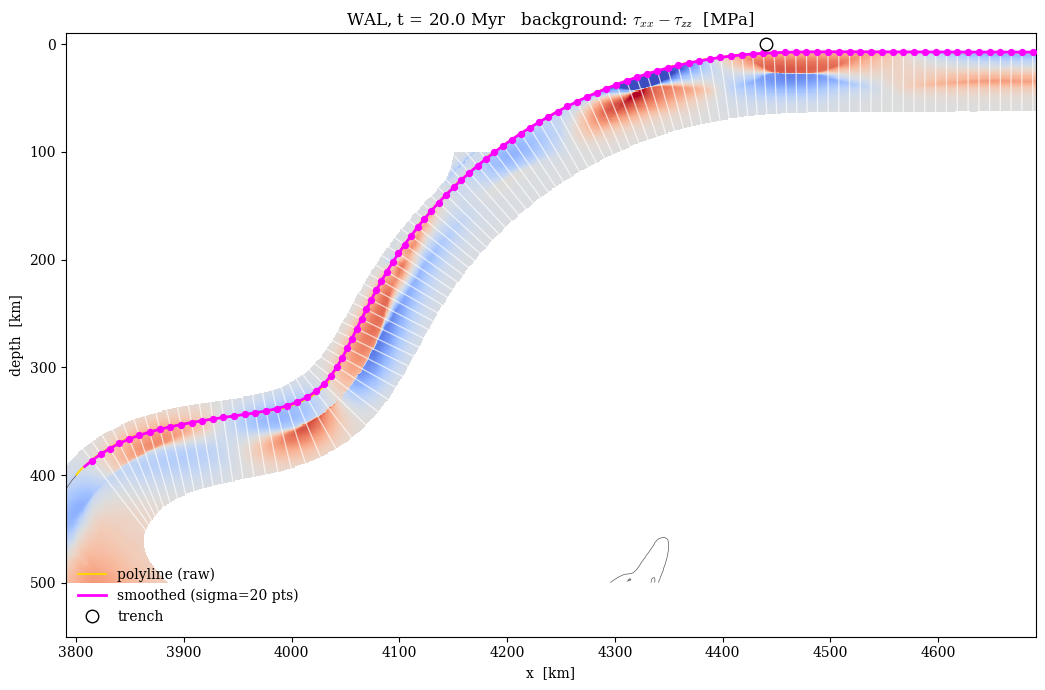

In [62]:
# ---- 8. Sanity-check figure (geometry) ------------------------------------
fig1, ax = plt.subplots(figsize=(13, 7))
#ax.pcolormesh(x*1e-3, z*1e-3, (txx - tzz) * 1e-6,
#              cmap='coolwarm', shading='auto', vmin=-300, vmax=+300)

#mask_grid = (SP > SP_THRESHOLD_MASK) & (T < T_MAX_K)  
shallow_grid = z[:, None] < DECOUPLING_DEPTH_KM * 1_000.0   # broadcasts to (nz, nx)                                                                                   
mask_grid = np.where(shallow_grid,                                                                                                                                     
                       (SP > SP_THRESHOLD_MASK) & (T < T_MAX_K),                                                                                                         
                       (T < T_MAX_K))   
diff_masked = np.where(mask_grid, (txx - tzz) * 1e-6, np.nan)
ax.pcolormesh(x*1e-3, z*1e-3, diff_masked,                                                                                                                             
                cmap='coolwarm', shading='auto', vmin=-300, vmax=+300)


for seg in segments:
    ax.plot(seg[:, 0]*1e-3, seg[:, 1]*1e-3, color='0.35', lw=0.5)
ax.plot(walk[:, 0]*1e-3, walk[:, 1]*1e-3, color='gold', lw=1.4,
        label='polyline (raw)')
ax.plot(slab_top[:, 0]*1e-3, slab_top[:, 1]*1e-3, color='magenta', lw=2.0,
        label=f'smoothed (sigma={SMOOTH_SIGMA_PTS} pts)')
for i in range(len(s_eval)):
    ax.plot(X_lines[i]*1e-3, Z_lines[i]*1e-3, color='white', lw=0.9, alpha=0.7)
ax.scatter(x_eval*1e-3, z_eval*1e-3, color='magenta', s=18, zorder=5)
ax.plot(tloc*1e-3, 0, 'wo', mec='k', ms=9, zorder=6, label='trench')
ax.invert_yaxis()
ax.set_xlim((tloc - 650e3)*1e-3, (tloc + 250e3)*1e-3)
ax.set_ylim(MAX_DEPTH_KM + 150, -10)
ax.set_aspect('equal')
ax.set_xlabel('x  [km]')
ax.set_ylabel('depth  [km]')
ax.set_title(f'{MODEL_KEY}, t = {t_yr/1e6:.1f} Myr   '
             r'background: $\tau_{xx} - \tau_{zz}$  [MPa]')
ax.legend(loc='lower left', frameon=False, fontsize=10)
fig1.tight_layout()



### $F_D$ along the slab top

Two plots:

- **Left:** $F_D$ vs arc length from the trench, $s = 0$ anchored at the trench. Negative $s$ = trailing plate; positive $s$ = into the slab. Both the slab-normal $F_D$ and its vertical projection $F_D\sin\theta$ shown (the latter sign-corrected to "downward = positive" in the plot).
- **Right:** the same quantities vs depth of the eval point.

$F_D\sin\theta$ is small in the trailing-plate region (slab is near-horizontal so $\theta \approx 0$) and grows toward $|F_D|$ as the slab steepens — pure projection geometry.

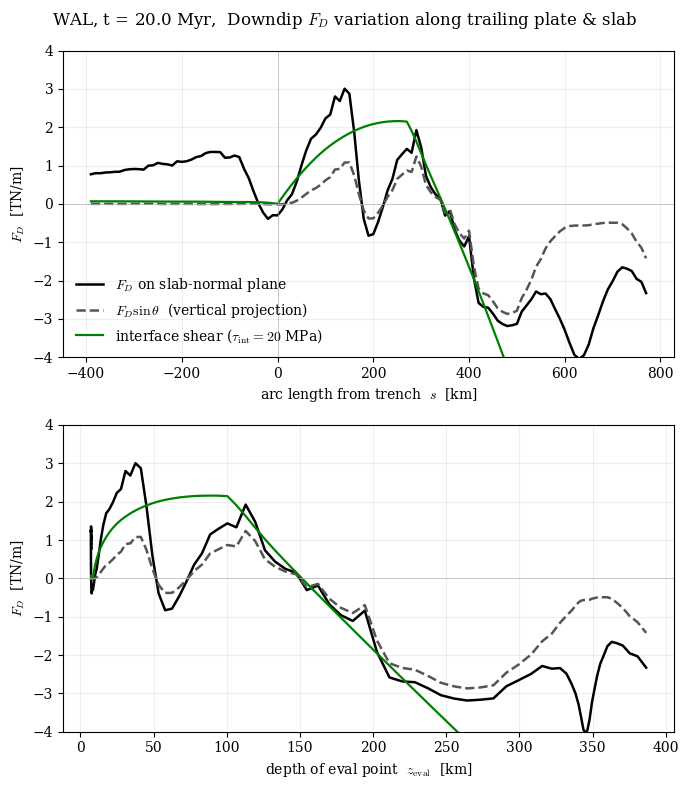

In [63]:
# ---- 9. F_D plots ---------------------------------------------------------
fig2, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(7, 8))

ax_a.plot(s_arc*1e-3, Fd_arr   * 1e-12, color='k',    ls='-',  lw=1.8,
          label=r'$F_D$ on slab-normal plane')
ax_a.plot(s_arc*1e-3, -Fd_v_arr * 1e-12, color='#555', ls='--', lw=1.8,
          label=r'$F_D \sin\theta$  (vertical projection)')

#ax_a.plot(s_arc*1e-3, -W_cum * 1e-12, color='r', ls='-', lw=1.6,                                                                                                      
#            label=r'cumulative down-dip buoyancy  $W_\mathrm{cum}$') 

#a_offset_x = 150
#a_offset_y = 2
#ax_a.plot(s_arc*1e-3 + a_offset_x, -W_cum * 1e-12 + a_offset_y, color='r', ls='--', lw=1.6,                                                                                                      
#            label=r'cumulative down-dip buoyancy  $W_\mathrm{cum}$') 

#ax_a.plot(s_arc*1e-3, -F_int_arr * 1e-12, color='green', ls='-', lw=1.6,
#            label=fr'interface shear ($\tau_\mathrm{{int}}={TAU_INTERFACE_MPA:.0f}$ MPa)')   

ax_a.plot(s_arc*1e-3, -W_cum * 1e-12  -F_int_arr * 1e-12, color='green', ls='-', lw=1.6,
            label=fr'interface shear ($\tau_\mathrm{{int}}={TAU_INTERFACE_MPA:.0f}$ MPa)')  

ax_a.axvline(0, color='0.7', lw=0.5)
ax_a.axhline(0, color='0.7', lw=0.5)
ax_a.set_xlabel(r'arc length from trench  $s$  [km]')
ax_a.set_ylabel(r'$F_D$  [TN/m]')
ax_a.legend(loc='best', frameon=False)
ax_a.grid(alpha=0.2)

ax_b.plot(z_eval*1e-3, Fd_arr   * 1e-12, color='k',    ls='-',  lw=1.8,
          label=r'$F_D$ on slab-normal plane')
ax_b.plot(z_eval*1e-3, -Fd_v_arr * 1e-12, color='#555', ls='--', lw=1.8,
          label=r'$F_D \sin\theta$')

#ax_b.plot(z_eval*1e-3, -W_cum * 1e-12, color='r', ls='-', lw=1.6,                                                                                                      
#            label=r'cumulative down-dip buoyancy  $W_\mathrm{cum}$')

#b_offset_x = 100
#ax_b.plot(z_eval*1e-3 + b_offset_x, -W_cum * 1e-12 + w_offset_y, color='r', ls='--', lw=1.6,                                                                                                      
#            label=r'cumulative down-dip buoyancy  $W_\mathrm{cum}$') 

                                                                                                                     
#ax_b.plot(z_eval*1e-3, -F_int_arr * 1e-12, color='green', ls='-', lw=1.6,
#            label=fr'interface shear ($\tau_\mathrm{{int}}={TAU_INTERFACE_MPA:.0f}$ MPa)')                                                                     

ax_b.plot(z_eval*1e-3, -W_cum * 1e-12  -F_int_arr * 1e-12, color='green', ls='-', lw=1.6,
            label=fr'interface shear ($\tau_\mathrm{{int}}={TAU_INTERFACE_MPA:.0f}$ MPa)')   

ax_b.axhline(0, color='0.7', lw=0.5)
ax_b.set_xlabel(r'depth of eval point  $z_\mathrm{eval}$  [km]')
ax_b.set_ylabel(r'$F_D$  [TN/m]')
#ax_b.legend(loc='best', frameon=False)
ax_b.grid(alpha=0.2)

ax_a.set_ylim(-4, 4)
ax_b.set_ylim(-4, 4)

fig2.suptitle(f'{MODEL_KEY}, t = {t_yr/1e6:.1f} Myr,  '
              r'Downdip $F_D$ variation along trailing plate & slab')
fig2.tight_layout()

fig2.savefig(figures_dir / f'Fd_along_slabtop_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',                                                                                      
               bbox_inches='tight', dpi=200) 

plt.show()

In [64]:
#(4e12/60e3)*1e-6

### Rotated differential stress on the full grid

Diagnostic visualisation. The rotation angle $\theta$ is computed at every grid cell by KDTree-querying its nearest sample on a dense parametrisation of the SP-boundary spline — same dip values the per-line F_D integration uses, just extended to the full grid. The rotated quantity

$$\tau_{\xi\xi} - \tau_{\eta\eta} \;=\; (\tau_{xx}-\tau_{zz})\cos 2\theta + 2\tau_{xz}\sin 2\theta$$

is then masked by the same depth-decoupled mask and rendered. What you see in slab-frame coordinates is exactly what the F_D integration is summing along each slab-normal line.

In [65]:
# Rotated differential stress on the full grid, masked + plotted.
#
# Drops into a fresh cell AFTER the slab-orthogonal-lines script, so it can
# reuse: x, z, X, Z, txx, tzz, txz, T, SP, spline_x, spline_z, s_raw,
# DS_PATH_M, MAX_DEPTH_KM, SP_THRESHOLD_MASK, T_MAX_K, slab_top, segments,
# walk, X_lines, Z_lines, x_eval, z_eval, tloc, MODEL_KEY, t_yr.

from scipy.spatial import cKDTree

# ---- 1. Dense-sample the slab-top spline ---------------------------------
s_dense = np.arange(0.0, s_raw[-1], DS_PATH_M)
x_dense = spline_x(s_dense)
z_dense = spline_z(s_dense)
dx_d    = spline_x(s_dense, 1)
dz_d    = spline_z(s_dense, 1)
dip_dense = np.arctan(dz_d / np.where(dx_d == 0, 1e-12, dx_d))

# ---- 2. Nearest-spline-sample dip per grid point -------------------------
tree = cKDTree(np.column_stack([x_dense, z_dense]))
_, ix_near = tree.query(np.column_stack([X.ravel(), Z.ravel()]))
dip_grid = dip_dense[ix_near].reshape(X.shape)

# X, Z from §4 are oriented (x, z); txx etc. are (z, x).  Transpose to match.
#dip_grid = dip_grid.T

# ---- 3. Rotated differential stress on the grid --------------------------
two_th = 2 * dip_grid
diff_rot_grid = (txx - tzz) * np.cos(two_th) + 2 * txz * np.sin(two_th)

# ---- 4. Mask (same as the F_D integration) -------------------------------
#mask_grid = (SP > SP_THRESHOLD_MASK) & (T < T_MAX_K)

shallow_grid = z[:, None] < DECOUPLING_DEPTH_KM * 1_000.0   # broadcasts to (nz, nx)                                                                                   
mask_grid = np.where(shallow_grid,                                                                                                                                     
                       (SP > SP_THRESHOLD_MASK) & (T < T_MAX_K),                                                                                                         
                       (T < T_MAX_K))   

diff_rot_masked = np.where(mask_grid, diff_rot_grid * 1e-6, np.nan)



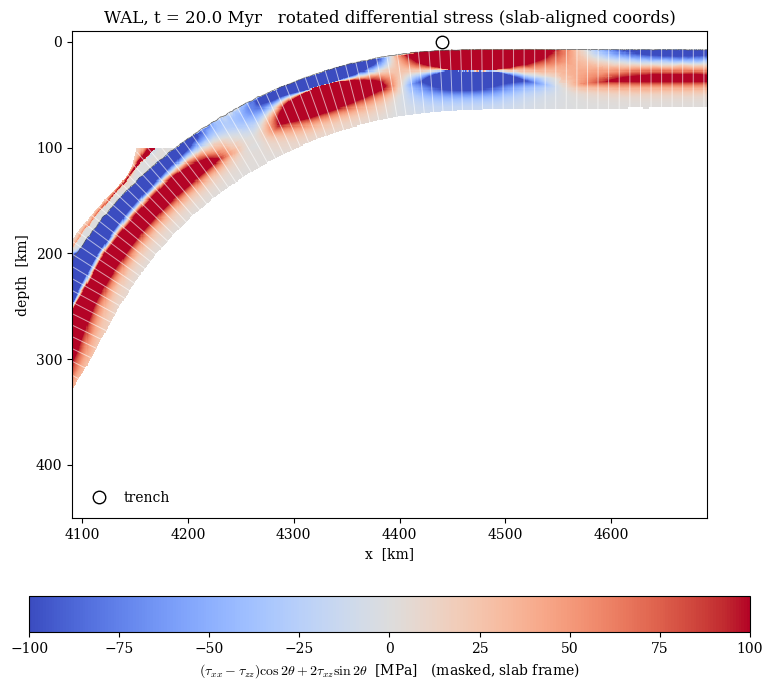

In [71]:

# ---- 5. Plot -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 7))

im = ax.pcolormesh(x*1e-3, z*1e-3, diff_rot_masked,
                   cmap='coolwarm', shading='auto', vmin=-100, vmax=+100)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal',
                    fraction=0.06, pad=0.13,
                    label=r'$(\tau_{xx}-\tau_{zz})\cos 2\theta + 2\tau_{xz}\sin 2\theta$  [MPa]   '
                          '(masked, slab frame)')

# SP=0.5 contour for reference
for seg in segments:
    ax.plot(seg[:, 0]*1e-3, seg[:, 1]*1e-3, color='0.35', lw=0.5)
#ax.plot(slab_top[:, 0]*1e-3, slab_top[:, 1]*1e-3, color='magenta', lw=2.0,
#        label='SP-boundary tracker (smoothed)')

# Slab-normal lines + eval points
for i in range(len(x_eval)):
    ax.plot(X_lines[i]*1e-3, Z_lines[i]*1e-3, color='white', lw=0.7, alpha=0.6)
#ax.scatter(x_eval*1e-3, z_eval*1e-3, color='magenta', s=14, zorder=5)

ax.plot(tloc*1e-3, 0, 'wo', mec='k', ms=9, zorder=6, label='trench')

ax.invert_yaxis()
ax.set_xlim((tloc - 350e3)*1e-3, (tloc + 250e3)*1e-3)
ax.set_ylim(MAX_DEPTH_KM + 50, -10)
ax.set_aspect('equal')
ax.set_xlabel('x  [km]')
ax.set_ylabel('depth  [km]')
ax.set_title(f'{MODEL_KEY}, t = {t_yr/1e6:.1f} Myr   '
             'rotated differential stress (slab-aligned coords)')
ax.legend(loc='lower left', frameon=False, fontsize=10)
fig.tight_layout()
fig.savefig(figures_dir / f'rotated_diff_stress_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',                                                                                    
              bbox_inches='tight', dpi=200)
plt.show()

/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_89293/2916562689.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


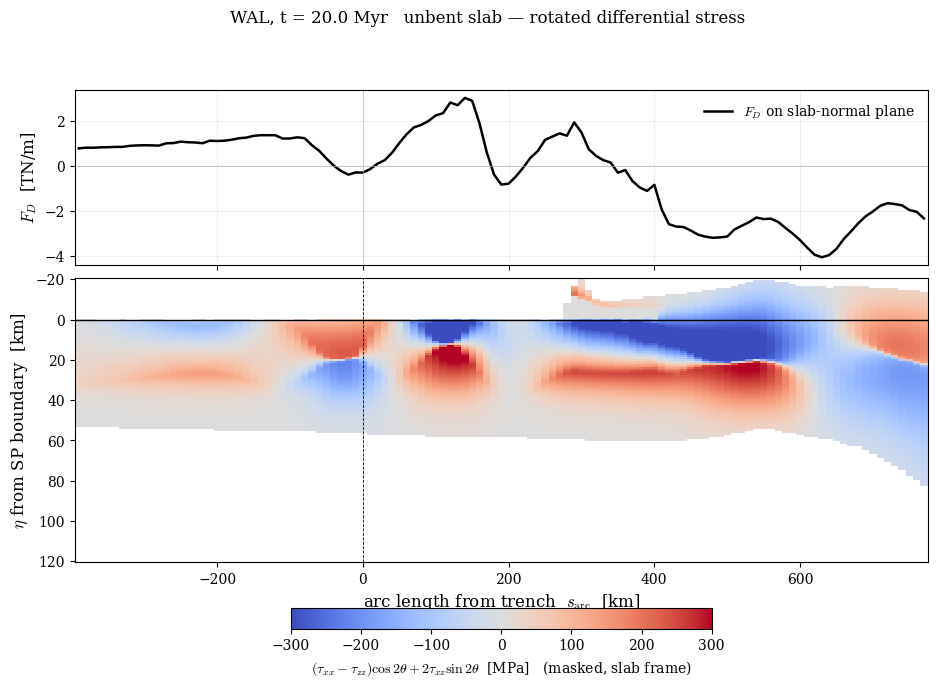

In [73]:
# Slab "unbent" visualisation: rotated differential stress in slab-aligned
# (s_arc, η) coordinates, as a flat rectangle.  Top panel: F_D vs s_arc.
# Bottom panel: pcolormesh of the rotated diff stress, x = arc length from
# trench, y = perpendicular distance from the SP boundary tracker.  Same
# masking and rotation as the curved-frame version.
#
# Drop into a fresh cell AFTER the slab-orthogonal-lines / buoyancy / interface
# pipeline.  Reuses: X_lines, Z_lines, s_local, s_arc, s_eval, dip_eval,
# Fd_arr, ftxx, ftzz, ftxz, fT, fSP, MODEL_KEY, t_yr,
# DECOUPLING_DEPTH_KM, SP_THRESHOLD_MASK, T_MAX_K.

import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Build the 2D stress grid in (s_arc, η) coords --------------------
n_pts_local = len(s_local)
n_eval      = len(s_eval)

stress_grid = np.full((n_pts_local, n_eval), np.nan)

for i in range(n_eval):
    pts   = np.column_stack([Z_lines[i], X_lines[i]])
    txx_p = ftxx(pts); tzz_p = ftzz(pts); txz_p = ftxz(pts)
    T_p   = fT(pts);   SP_p  = fSP(pts)

    two_th   = 2 * dip_eval[i]
    diff_rot = (txx_p - tzz_p) * np.cos(two_th) + 2 * txz_p * np.sin(two_th)

    z_along      = pts[:, 0]
    shallow      = z_along < DECOUPLING_DEPTH_KM * 1_000.0
    mask_shallow = (SP_p > SP_THRESHOLD_MASK) & (T_p < T_MAX_K)
    mask_deep    = (T_p < T_MAX_K)
    keep         = np.where(shallow, mask_shallow, mask_deep) & np.isfinite(diff_rot)

    stress_grid[:, i] = np.where(keep, diff_rot, np.nan)

# ---- 2. Plot --------------------------------------------------------------
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.05},
)

# Top: F_D vs arc length
ax_top.plot(s_arc * 1e-3, Fd_arr * 1e-12, color='k', lw=1.8,
            label=r'$F_D$ on slab-normal plane')
ax_top.axhline(0, color='0.7', lw=0.5)
ax_top.axvline(0, color='0.7', lw=0.5)
ax_top.set_ylabel(r'$F_D$  [TN/m]', fontsize=12)
ax_top.legend(loc='best', frameon=False, fontsize=10)
ax_top.grid(alpha=0.2)

# Bottom: unbent slab — rotated diff stress on (s_arc, η) grid
im = ax_bot.pcolormesh(s_arc * 1e-3, s_local * 1e-3, stress_grid * 1e-6,
                       cmap='coolwarm', shading='auto', vmin=-300, vmax=+300)

ax_bot.axhline(0, color='k', lw=1.0)            # SP boundary tracker
ax_bot.axvline(0, color='k', lw=0.6, ls='--')   # trench
ax_bot.invert_yaxis()                           # positive η (into slab) downward

ax_bot.set_xlabel(r'arc length from trench  $s_\mathrm{arc}$  [km]', fontsize=12)
ax_bot.set_ylabel(r'$\eta$ from SP boundary  [km]', fontsize=12)

cbar = fig.colorbar(im, ax=ax_bot, orientation='horizontal',
                    fraction=0.06, pad=0.13,
                    label=r'$(\tau_{xx}-\tau_{zz})\cos 2\theta + 2\tau_{xz}\sin 2\theta$  [MPa]   '
                          '(masked, slab frame)')

fig.suptitle(f'{MODEL_KEY}, t = {t_yr/1e6:.1f} Myr   '
             'unbent slab — rotated differential stress',
             y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Down-dip force balance — open issues and next steps

Captures the state of the slab-parallel force-balance work after the first round (F_D, cumulative buoyancy, analytical interface shear), the theoretical pieces still missing from a complete balance analogous to the trailing-plate horizontal balance, and a staged plan for closing it.

---

## 1. State of play

What's currently computed at each eval point along the SP-boundary tracker:

| quantity | physical meaning |
|---|---|
| `Fd_arr` | $F_D = \int(\tau_{\xi\xi}-\tau_{\eta\eta})\,d\eta$ on each slab-normal plane |
| `Fd_v_arr` | $F_D \sin\theta$ — vertical projection of the slab-parallel resultant |
| `Fd_h_arr` | $F_D \cos\theta$ — horizontal projection |
| `W_cum` | $g\int_0^\xi \sin\theta\cdot\Sigma\,d\xi'$ — cumulative down-dip buoyancy from the trench |
| `F_int_arr` | $-\tau_\mathrm{int}\cdot s$ — analytical interface shear, capped at the decoupling depth |

First-order observation: $F_D \approx W_\mathrm{cum} + F_\mathrm{int}$ holds remarkably well across the slab. The change in $F_D$ along the slab is largely explained by the cumulative slab-parallel weight, with the interface shear closing the residual gap above the decoupling depth.

---

## 2. The complete slab-parallel force balance

Analog of the trailing-plate horizontal balance, derived by integrating $\partial_j \sigma_{ij} = -\rho g_i$ over a slab segment and projecting onto the slab-parallel direction $\hat{\xi}$:

$$\Delta F_D(\xi) \;-\; \Delta\mathrm{GPE}^*_\eta(\xi) \;+\; F_\mathrm{basal}(\xi) \;-\; F_\mathrm{int}(\xi) \;+\; W_\mathrm{cum}(\xi) \;+\; C_\mathrm{curv}(\xi) \;\approx\; 0$$

| term | definition | analog in horizontal balance |
|---|---|---|
| $\Delta F_D$ | $\Delta\int(\tau_{\xi\xi}-\tau_{\eta\eta})\,d\eta$ | $\Delta F_D$ |
| $\Delta\mathrm{GPE}^*_\eta$ | $\Delta\bigl[-\int\sigma_{\eta\eta}\,d\eta\bigr]$ | $\Delta\mathrm{GPE}^*$ |
| $F_\mathrm{basal}$ | $\int\sigma_{\xi\eta}(\eta=H)\,d\xi$ | $F_B$ (single basal traction) |
| $F_\mathrm{int}$ | $\int\sigma_{\xi\eta}(\eta=0)\,d\xi$ | (no analog — only one shear boundary in the trailing plate) |
| $W_\mathrm{cum}$ | $g\int\sin\theta\cdot\Sigma\,d\xi$ | (no analog — gravity is perpendicular to integration direction in horizontal balance) |
| $C_\mathrm{curv}$ | curvature coupling — see §5 | (no analog — straight integration path) |

Of these, only $\Delta F_D$, $W_\mathrm{cum}$, and an *analytical* estimate of $F_\mathrm{int}$ are currently computed. The four open pieces — the slab-normal pressure resultant ($\Delta\mathrm{GPE}^*_\eta$), the *measured* basal and interface shears, and the curvature correction — each have practical estimation problems.

---

## 3. Practical challenge: top and bottom of the slab are not cleanly defined

The SP=0.5 contour gives a usable slab-top tracker (already in use). The slab BOTTOM is fuzzier:

- An isotherm could mark the bottom (e.g. T = 1273 K, the same threshold used in the mask), but its perpendicular distance from the SP-boundary tracker varies along $\xi$ — the slab thickens as it cools the surrounding mantle (the same thermal-halo issue that motivated the depth-decoupled mask).
- Variable slab thickness $H(\xi)$ couples directly into $\mathrm{GPE}^*_\eta$, which contains the lithostatic pressure $\rho g \cos\theta\cdot\eta$ integrated across thickness. A 30 km change in $H$ can shift $\mathrm{GPE}^*_\eta$ by tens of TN/m — the same magnitude as $F_D$ itself.
- The cumulative *difference* $\Delta\mathrm{GPE}^*_\eta(\xi)$ is what enters the balance, so a clean subtraction of the lithostatic baseline is essential.

**Open question.** Is it cleaner to (a) keep using a fixed bilateral slab-normal length and rely on the mask to truncate, or (b) use a thermally-defined slab thickness and explicitly subtract the lithostatic baseline before differencing?

---

## 4. Practical challenge: shear stresses at the top and bottom are noisy

$\sigma_{\xi\eta}$ on the slab boundaries is structurally hard to extract:

- The top boundary above the decoupling depth is the megathrust — narrow, high-gradient, with the weak-layer rheology. Sampling $\sigma_{\xi\eta}$ there gets you values dominated by gridscale artefacts of the interface treatment.
- The bottom is the slab/asthenosphere thermal boundary layer. Less violent but still a stress-gradient zone.
- Below the decoupling depth, both the top and bottom interfaces are mantle/mantle (no megathrust on top, no warm-asthenosphere overshoot on bottom). Stresses here are likely smoother and smaller.

**Validation strategy.** Restrict the balance test to the regime $z_\mathrm{eval} > \mathrm{DECOUPLING\_DEPTH\_KM}$ (~125 km) for the first several hundred km of arc length. In that regime:

- The top is asthenosphere (slab/mantle interface). Both top and bottom are mantle/mantle.
- Hypothesis: $F_\mathrm{basal}$ and $F_\mathrm{int}$ are second-order. The balance should close without them.
- If the closure $\Delta F_D - \Delta\mathrm{GPE}^*_\eta + W_\mathrm{cum} + C_\mathrm{curv} \approx 0$ holds in this regime, the underlying physics is captured. The shear terms become a residual correction needed only in the megathrust region above decoupling.

This staged approach is much cleaner than trying to extract noisy boundary tractions from the start.

---

## 5. Curvature coupling — the bending-force term

The horizontal balance assumes a straight integration path. The slab is curved, and the slab-normal direction $\hat{\eta}(\xi)$ rotates as $\xi$ advances. The proper way to handle this is to write the slab-parallel force balance in *curvilinear* (slab-aligned) coordinates and use the membrane equation from thin-plate theory:

$$\frac{dN}{d\xi} + \kappa(\xi)\, V(\xi) \;=\; q_\xi(\xi)$$

with $\kappa = d\theta/d\xi$ the local curvature, $N = \int\sigma_{\xi\xi}\,d\eta = F_D - \mathrm{GPE}^*_\eta$ the membrane resultant, and

$$V(\xi) \;=\; \int_0^H \sigma_{\xi\eta}\,d\eta$$

the **transverse-stress resultant** on the slab-normal plane — the down-dip analog of $V(x) = \int_0^{z_c}\sigma_{xz}\,dz$ from the horizontal-balance discussion. In the trailing-plate (horizontal) balance, $V(x)$ is the depth-integrated vertical shear used to relate surface deflection to $\partial_x V$. Here, $V(\xi)$ is the slab-thickness-integrated transverse shear on the slab-normal plane — same construction, rotated frame.

In the original (horizontal) balance $V$ does not enter the trailing-plate force balance because the integration path is straight and the force balance is projected onto a fixed direction. In the slab-parallel balance the integration path is curved, the $\hat{\xi}$ direction rotates between successive slab-normal planes, and $V$ at one plane has a small slab-parallel component at the next plane — that's the curvature coupling.

The right-hand side $q_\xi$ collects the body-force and surface-traction contributions: $-\rho g\sin\theta\cdot\Sigma$, $\sigma_{\xi\eta}^{(\mathrm{top})}$, $\sigma_{\xi\eta}^{(\mathrm{bottom})}$.

Integrating along $\xi$:

$$\Delta N(\xi) + \int_0^\xi \kappa(\xi')\,V(\xi')\,d\xi' \;=\; -W_\mathrm{cum}(\xi) + F_\mathrm{int}(\xi) - F_\mathrm{basal}(\xi)$$

so the **complete cumulative balance** is

$$\boxed{\;\Delta F_D - \Delta\mathrm{GPE}^*_\eta + C_\mathrm{curv} + W_\mathrm{cum} - F_\mathrm{int} + F_\mathrm{basal} \;\approx\; 0\;}$$

with

$$C_\mathrm{curv}(\xi) \;\equiv\; \int_0^\xi \kappa(\xi')\,V(\xi')\,d\xi'$$

### Why this term is the "bending force" of slab-pull literature

In thin-plate theory the transverse shear $V$ is the gradient of the bending moment ($dM/d\xi = V$ in the absence of external moments). Bending stresses inside the slab — the cold core in tension on the convex side and compression on the concave side, classically — integrate to zero net membrane force but produce a non-zero $V$ when their distribution is asymmetric across the slab thickness. So $\kappa V$ is the contribution to the membrane balance from bending stresses *coupled through the geometric curvature*. That's the term often called "bending dissipation" or "bending force" in slab-pull energy budgets.


### Practical observations

- $\kappa$ is small ($\sim 10^{-3}$ rad/km — dip changes tens of degrees over hundreds of km).
- $V$ is the *integrated* slab-normal shear on the slab-normal plane — typically a fraction of the total stress magnitudes; could be of order tens of TN/m for a strongly-bending slab, much smaller for a mostly-coasting one.
- Their product accumulated over arc length is the full bending contribution; could be small or large depending on whether the slab is actively bending.
- Sign convention: with $\kappa > 0$ for slab steepening with depth and $V$ following the slab-normal direction convention used elsewhere, $C_\mathrm{curv}$ has the sign of the cumulative bending-force work along the slab.

### Computation — no explicit curvature needed

$\kappa\,d\xi = d\theta$ exactly, so the curvature coupling can be evaluated by differencing the dip directly between consecutive eval points and weighting by $V$ — no spline second derivatives, no $\kappa$ computation, no extra geometry. The continuous integral

$$C_\mathrm{curv}(\xi) \;=\; \int_0^\xi V(\xi')\,\kappa(\xi')\,d\xi' \;\equiv\; \int_0^\xi V(\xi')\,d\theta(\xi')$$

becomes the discrete cumulative sum

$$C_\mathrm{curv,k} \;=\; \sum_{j=1}^{k} V_{j-\frac{1}{2}}\,(\theta_j - \theta_{j-1})$$

i.e. just $V$ at each segment times the dip change between successive slab-normal planes:

```python
# V from σ_ξη on each slab-normal line (rotated shear, then integrate through slab thickness)
sigma_xi_eta = 0.5*(txx_p - tzz_p)*np.sin(two_th) + txz_p*np.cos(two_th)
V_arr[i] = np.trapz(sigma_xi_eta[keep], s_local[keep])

# After the loop: cumulative coupling, no κ required
delta_theta = np.diff(dip_eval)                            # dip change between successive eval points
V_mid       = 0.5 * (V_arr[:-1] + V_arr[1:])               # midpoint V on each segment
C_curv      = np.concatenate([[0.0], np.cumsum(V_mid * delta_theta)])
C_curv     -= C_curv[i_trench]
```

The same pattern generalises to *every* resultant we compute: any resultant on a slab-normal plane that has a slab-parallel component (and there are several) gets a curvature-coupling contribution that can be evaluated as $\text{resultant} \times \Delta\theta$ summed between successive planes. No curvature computation required for any of them.

### Optional validation via explicit $\kappa$

If you want to cross-check the differencing approach, compute $\kappa$ from the spline and integrate $\int\kappa V\,d\xi$ — should give the same $C_\mathrm{curv}$ to machine precision modulo discretisation:

```python
# Optional: explicit κ from spline second derivatives, for validation only
ddx = spline_x(s_eval, 2); ddz = spline_z(s_eval, 2)
kappa_arr = (dxds*ddz - dzds*ddx) / (dxds**2 + dzds**2)**1.5
C_curv_explicit = cumulative_trapezoid(kappa_arr * V_arr, s_arc, initial=0.0)
C_curv_explicit -= C_curv_explicit[i_trench]
# np.allclose(C_curv, C_curv_explicit) should pass within trapezoid error
```

Useful as a sanity test when you first add this term. After confirming agreement, drop the spline-curvature path and use the differencing one.

---

## 6. Implementation roadmap

### Phase 1 — Add $\Delta\mathrm{GPE}^*_\eta$ to the existing balance

Per eval point, in the same loop that computes $F_D$:

```python
# σ_ηη in rotated frame
sigma_eta_eta = (txx_p + tzz_p)/2 - (txx_p - tzz_p)/2 * np.cos(two_th) - txz_p * np.sin(two_th)
GPE_eta_arr[i] = -np.trapz(sigma_eta_eta[keep], s_local[keep])
```

then anchor the difference at the trench: $\Delta\mathrm{GPE}^*_\eta(\xi) = \mathrm{GPE}^*_\eta(\xi) - \mathrm{GPE}^*_\eta(0)$.

Plot $\Delta F_D - \Delta\mathrm{GPE}^*_\eta + W_\mathrm{cum}$ vs $s_\mathrm{arc}$. If this hugs zero in the deep regime, $F_\mathrm{basal}$ and $F_\mathrm{int}$ are confirmed second-order there.

### Phase 2 — Add the curvature correction

```python
# κ from the spline second derivatives
ddx = spline_x(s_eval, 2); ddz = spline_z(s_eval, 2)
kappa = (dxds * ddz - dzds * ddx) / (dxds**2 + dzds**2)**1.5
# Cumulative curvature × GPE_η correction
C_curv = -cumulative_trapezoid(kappa * GPE_eta_arr, s_arc, initial=0.0)
C_curv -= C_curv[i_trench]
```

If Phase 1 closed in the deep regime, Phase 2 should close it across the curved trench-bend region too.

### Phase 3 — Measure the boundary shear tractions

Only after Phases 1 and 2 are validated. Sample $\sigma_{\xi\eta}$ at the slab top ($\eta=0$) and slab bottom ($\eta=H$ — definition still TBD per §3), integrate along $\xi$. Compare measured $F_\mathrm{int}$ against the analytical $\tau_\mathrm{int}\cdot s$ approximation; compare measured $F_\mathrm{basal}$ against zero.

The expected answer above the decoupling depth: measured $F_\mathrm{int}$ matches the analytical line, measured $F_\mathrm{basal}$ is small. Below the decoupling depth: both should be small.

### Phase 4 — Test slab-thickness dependence of $\mathrm{GPE}^*_\eta$

Once everything else is settled: vary `SLAB_NORMAL_DOWN_KM` and check that the closure is insensitive — i.e. that the lithostatic baseline subtracts cleanly via the differencing.

---

## 7. Variables to add

If the implementation goes ahead:

```python
GPE_eta_arr     # ∫(-σ_ηη)dη per eval point  [N/m]
DGPE_eta_arr    # GPE_eta_arr - GPE_eta_arr[i_trench]
kappa_arr       # local curvature  [1/m]
C_curv          # cumulative curvature correction  [N/m]
F_basal_arr     # measured basal shear, cumulative  [N/m]
F_int_meas      # measured interface shear, cumulative  [N/m]
residual        # ΔF_D − ΔGPE_η* + F_basal − F_int_meas + W_cum + C_curv
```

---

## 8. Open theoretical questions

- The horizontal balance assumed "hydrostatic at $z_c$" to identify pressure with $-\sigma_{zz}$. The slab-parallel balance has no equivalent simplifying assumption — $\sigma_{\eta\eta}$ varies across the slab thickness as the asthenosphere/slab/asthenosphere column transitions through different material strengths. Whether the "lithostatic baseline" subtraction works cleanly depends on this variation being smooth.
- The analytical $F_\mathrm{int}$ assumed constant $\tau_\mathrm{int}$. In the model this is set by the weak-layer rheology and may vary along the megathrust. A measured $F_\mathrm{int}$ would replace the assumption — but at the cost of the noise issue from §4.
- The curvature term assumes the slab cross-section maintains its shape as the slab descends (the same slab-normal line "sees" the same physical material at neighbouring eval points). For strong bending or boudinage this would fail.


